In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [25]:
#advanced logistic regression
df=pd.read_csv("fraud_detection.csv")
df.head(15)

,transaction_amount,transaction_risk_score,is_fraud
0,1.879910,-1.485035,0
1,0.377083,-2.238585,0
2,1.354312,-2.664638,0
3,-0.509843,-1.502950,0
4,0.863561,-1.906364,0
5,0.406815,-0.981403,0
6,1.709547,-0.214663,0
7,1.810488,-1.471487,0
8,0.235650,1.231847,0
9,1.886285,-1.278440,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_amount      10000 non-null  float64
 1   transaction_risk_score  10000 non-null  float64
 2   is_fraud                10000 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 234.5 KB


In [27]:
df["is_fraud"].value_counts()

is_fraud
0    9846
1     154
Name: count, dtype: int64

In [28]:
X=df.drop("is_fraud", axis=1)
y=df["is_fraud"]

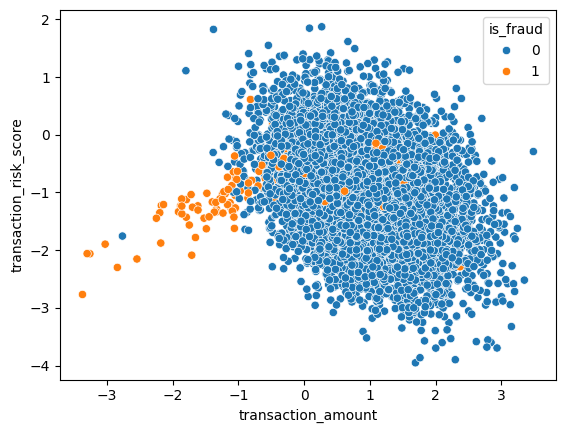

In [29]:
sns.scatterplot(x=X["transaction_amount"], y=X["transaction_risk_score"], hue=y)
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=34)
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [31]:
penalty=["l1", "l2", "elasticnet"]
c_values=[0.01, 0.1, 1, 10, 100]
solver=["newton-cg", "lbfgs","liblinear", "sag" "saga", "newton-cholesky"]
class_weight=[{0:w, 1:y} for w in [1,10,50,100] for y in [1,10,50,100]]

In [32]:
params=dict(penalty=penalty, C=c_values, solver=solver, class_weight=class_weight)
from sklearn.model_selection import GridSearchCV,StratifiedKFold
grid=GridSearchCV(estimator=model, param_grid=params, scoring="accuracy", n_jobs=-1)
import warnings
warnings.filterwarnings("ignore")
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

In [33]:
y_pred=grid.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2500,))

In [34]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
print("score:", accuracy_score(y_pred, y_test)) 
print(classification_report(y_pred, y_test))
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))

score: 0.9892
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2483
           1       0.38      0.94      0.54        17

    accuracy                           0.99      2500
   macro avg       0.69      0.97      0.77      2500
weighted avg       1.00      0.99      0.99      2500

confusion matrix: 
 [[2457   26]
 [   1   16]]


In [35]:
grid.best_params_

{'C': 0.01,
 'class_weight': {0: 10, 1: 50},
 'penalty': 'l2',
 'solver': 'newton-cg'}

In [36]:
grid.best_score_

np.float64(0.9886666666666667)

In [37]:
#roc, auc
model_prob=grid.predict_proba(X_test)
model_prob= model_prob[:,1] #probability of being 1
model_prob

array([0.27506339, 0.06508621, 0.08899226, ..., 0.0079752 , 0.00675222,
       0.14903522], shape=(2500,))

In [38]:
from sklearn.metrics import roc_auc_score, roc_curve
model_auc=roc_auc_score(y_test, model_prob)
model_auc

0.7626506257507071

In [39]:
roc_curve(y_test, model_prob)

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.06834825e-04,
        4.06834825e-04, 2.03417413e-03, 2.03417413e-03, 4.88201790e-03,
        4.88201790e-03, 1.42392189e-02, 1.42392189e-02, 2.76647681e-02,
        2.76647681e-02, 4.06834825e-02, 4.06834825e-02, 5.32953621e-02,
        5.32953621e-02, 8.74694874e-02, 8.74694874e-02, 1.20423108e-01,
        1.20423108e-01, 1.89178194e-01, 1.89178194e-01, 2.00569569e-01,
        2.00569569e-01, 2.05451587e-01, 2.05451587e-01, 2.75427177e-01,
        2.75427177e-01, 3.57200976e-01, 3.57200976e-01, 3.61676159e-01,
        3.61676159e-01, 4.58096013e-01, 4.58096013e-01, 5.23189585e-01,
        5.23189585e-01, 5.58177380e-01, 5.58177380e-01, 5.63059398e-01,
        5.63059398e-01, 6.83482506e-01, 6.83482506e-01, 6.93246542e-01,
        6.93246542e-01, 8.03091945e-01, 8.03091945e-01, 8.69406021e-01,
        8.69406021e-01, 9.25956062e-01, 9.25956062e-01, 9.46297803e-01,
        9.46297803e-01, 9.61757526e-01, 9.61757526e-01, 1.000000

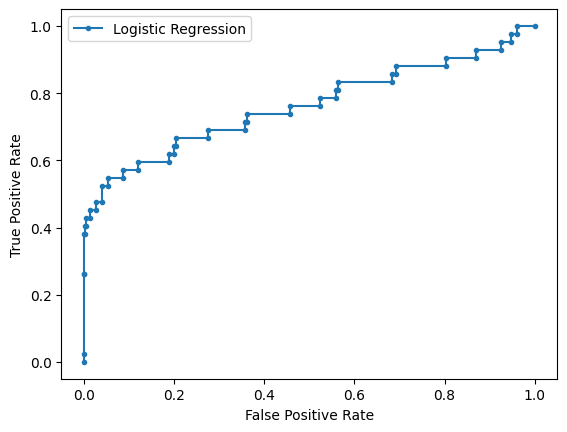

In [40]:
model_fpr, model_tpr, thresholds=roc_curve(y_test, model_prob)
plt.plot(model_fpr, model_tpr, marker=".",label="Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

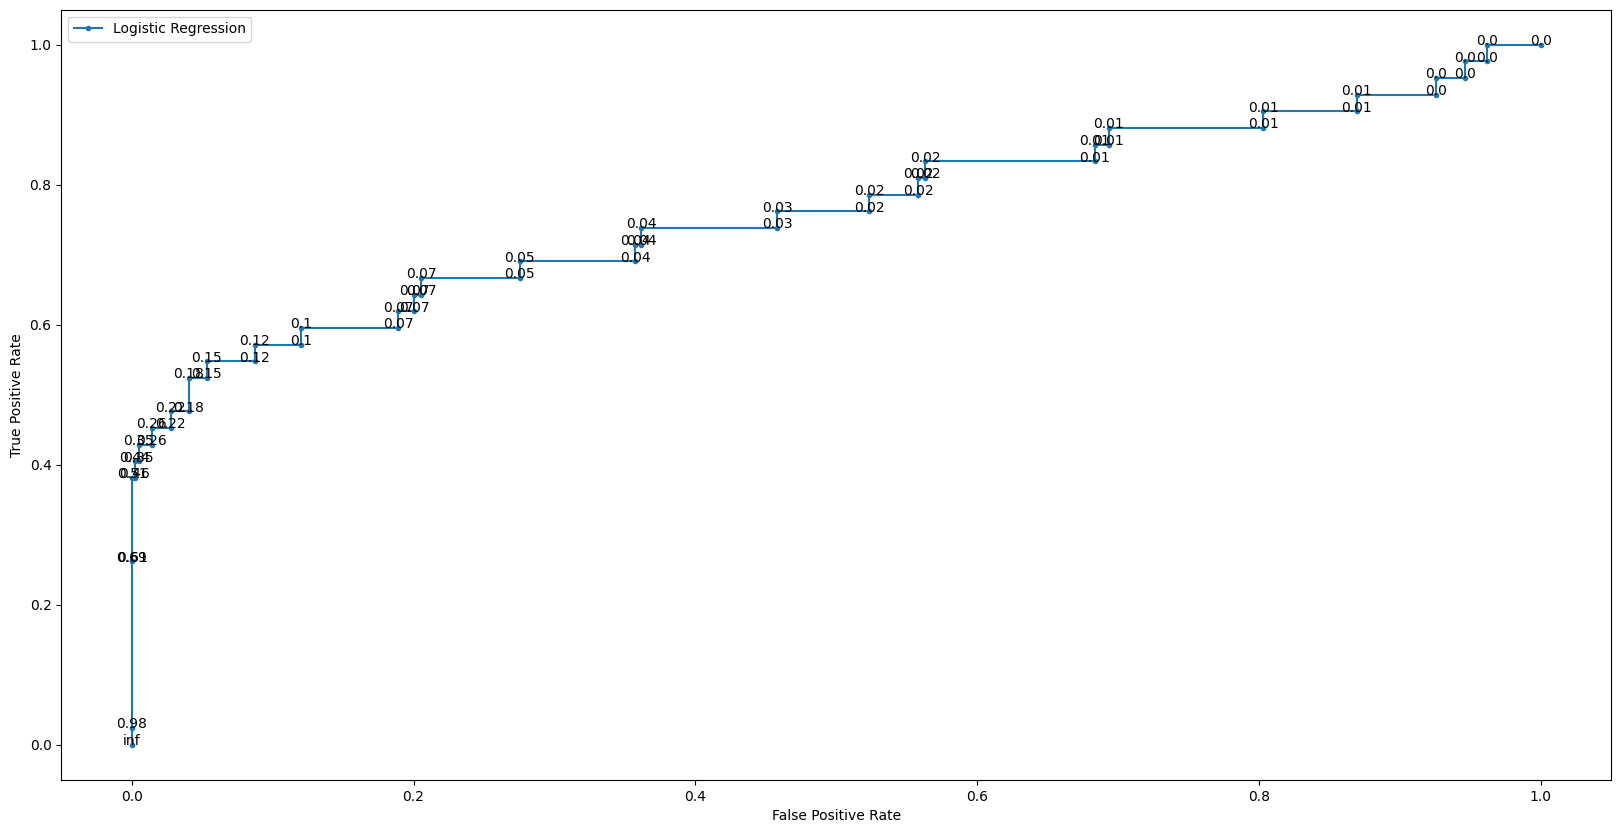

In [41]:
fig,ax=plt.subplots(figsize=(20,10))
ax.plot(model_fpr, model_tpr, marker=".",label="Logistic Regression")

for fpr, tpr, threshold in zip(model_fpr, model_tpr, thresholds):
    ax.annotate(f"{np.round(threshold, 2)}", (fpr, tpr), ha='center')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.show()

In [48]:
custom_threshold=0.5
y_pred_custom=(model_prob>=custom_threshold).astype(int)
y_pred_custom

array([0, 0, 0, ..., 0, 0, 0], shape=(2500,))

In [49]:
print(confusion_matrix(y_pred_custom, y_test))
print(classification_report(y_pred_custom, y_test))

[[2457   26]
 [   1   16]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2483
           1       0.38      0.94      0.54        17

    accuracy                           0.99      2500
   macro avg       0.69      0.97      0.77      2500
weighted avg       1.00      0.99      0.99      2500

